<a href="https://colab.research.google.com/github/Wambui-123/Predictive-Analysis-of-Housing-and-Rental-Prices-in-German-Metropolitan-Areas/blob/feature%2Fhousing-prediction/Predictive_Analysis_of_Apartment_Rental_Prices_in_Germany_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Make plots show nicely in Colab
%matplotlib inline

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
df = pd.read_csv("/content/immo_data.csv", on_bad_lines='skip')

print("Dataset loaded. Shape:", df.shape)
df.head()

Dataset loaded. Shape: (4010, 49)


,regio1,serviceCharge,heatingType,telekomTvOffer,telekomHybridUploadSpeed,newlyConst,balcony,picturecount,pricetrend,telekomUploadSpeed,...,regio2,regio3,description,facilities,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice,date
0,Nordrhein_Westfalen,245.00,central_heating,ONE_YEAR_FREE,NaN,False,False,6,4.62,10.0,...,Dortmund,Schüren,Die ebenerdig zu erreichende Erdgeschosswohnun...,Die Wohnung ist mit Laminat ausgelegt. Das Bad...,NaN,NaN,NaN,NaN,NaN,May19
1,Rheinland_Pfalz,134.00,self_contained_central_heating,ONE_YEAR_FREE,NaN,False,True,8,3.47,10.0,...,Rhein_Pfalz_Kreis,Böhl_Iggelheim,Alles neu macht der Mai – so kann es auch für ...,NaN,NaN,NaN,2019.0,NaN,NaN,May19
2,Sachsen,255.00,floor_heating,ONE_YEAR_FREE,10.0,True,True,8,2.72,2.4,...,Dresden,Äußere_Neustadt_Antonstadt,Der Neubau entsteht im Herzen der Dresdner Neu...,"* 9 m² Balkon\n* Bad mit bodengleicher Dusche,...",NaN,NaN,NaN,NaN,NaN,Oct19
3,Sachsen,58.15,district_heating,ONE_YEAR_FREE,NaN,False,True,9,1.53,40.0,...,Mittelsachsen_Kreis,Freiberg,Abseits von Lärm und Abgasen in Ihre neue Wohn...,NaN,87.23,NaN,NaN,NaN,NaN,May19
4,Bremen,138.00,self_contained_central_heating,NaN,NaN,False,True,19,2.46,NaN,...,Bremen,Neu_Schwachhausen,Es handelt sich hier um ein saniertes Mehrfami...,Diese Wohnung wurde neu saniert und ist wie fo...,NaN,NaN,NaN,NaN,NaN,Feb20


In [ ]:
print("\n--- BASIC INFO ---")
df.info()

print("\n--- SUMMARY STATISTICS ---")
df.describe(include="all")

print("\n--- MISSING VALUES ---")
df.isna().sum()



--- BASIC INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4010 entries, 0 to 4009
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   regio1                    4010 non-null   object 
 1   serviceCharge             3903 non-null   float64
 2   heatingType               3293 non-null   object 
 3   telekomTvOffer            3538 non-null   object 
 4   telekomHybridUploadSpeed  689 non-null    float64
 5   newlyConst                4010 non-null   bool   
 6   balcony                   4010 non-null   bool   
 7   picturecount              4010 non-null   int64  
 8   pricetrend                3989 non-null   float64
 9   telekomUploadSpeed        3530 non-null   float64
 10  totalRent                 3432 non-null   float64
 11  yearConstructed           3136 non-null   float64
 12  scoutId                   4010 non-null   int64  
 13  noParkSpaces              1345 non-null   f

,0
regio1,0
serviceCharge,107
heatingType,717
telekomTvOffer,472
telekomHybridUploadSpeed,3321
newlyConst,0
balcony,0
picturecount,0
pricetrend,21
telekomUploadSpeed,480


In [ ]:
useful_columns = [
    "baseRent",        # target variable
    "livingSpace",
    "noRooms", # Corrected from 'numberOfRooms'
    "yearConstructed",
    "regio1",
    "regio2"
]

df_small = df[useful_columns].copy()
df_small.head()

,baseRent,livingSpace,noRooms,yearConstructed,regio1,regio2
0,595.0,86.00,4.0,1965.0,Nordrhein_Westfalen,Dortmund
1,800.0,89.00,3.0,1871.0,Rheinland_Pfalz,Rhein_Pfalz_Kreis
2,965.0,83.80,3.0,2019.0,Sachsen,Dresden
3,343.0,58.15,3.0,1964.0,Sachsen,Mittelsachsen_Kreis
4,765.0,84.97,3.0,1950.0,Bremen,Bremen


In [ ]:
# Drop rows with missing target or key features
df_small = df_small.dropna(subset=["baseRent", "livingSpace", "noRooms"])

# Fill yearConstructed missing with median
df_small["yearConstructed"] = df_small["yearConstructed"].fillna(df_small["yearConstructed"].median())

# Fill region missing with "Unknown"
df_small["regio1"] = df_small["regio1"].fillna("Unknown")
df_small["regio2"] = df_small["regio2"].fillna("Unknown")

print("Remaining missing values:")
df_small.isna().sum()

Remaining missing values:


,0
baseRent,0
livingSpace,0
noRooms,0
yearConstructed,0
regio1,0
regio2,0


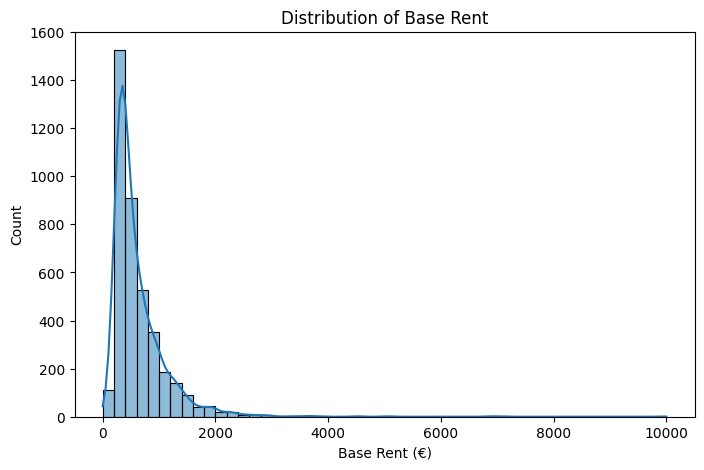

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_small["baseRent"], bins=50, kde=True)
plt.title("Distribution of Base Rent")
plt.xlabel("Base Rent (€)")
plt.show()


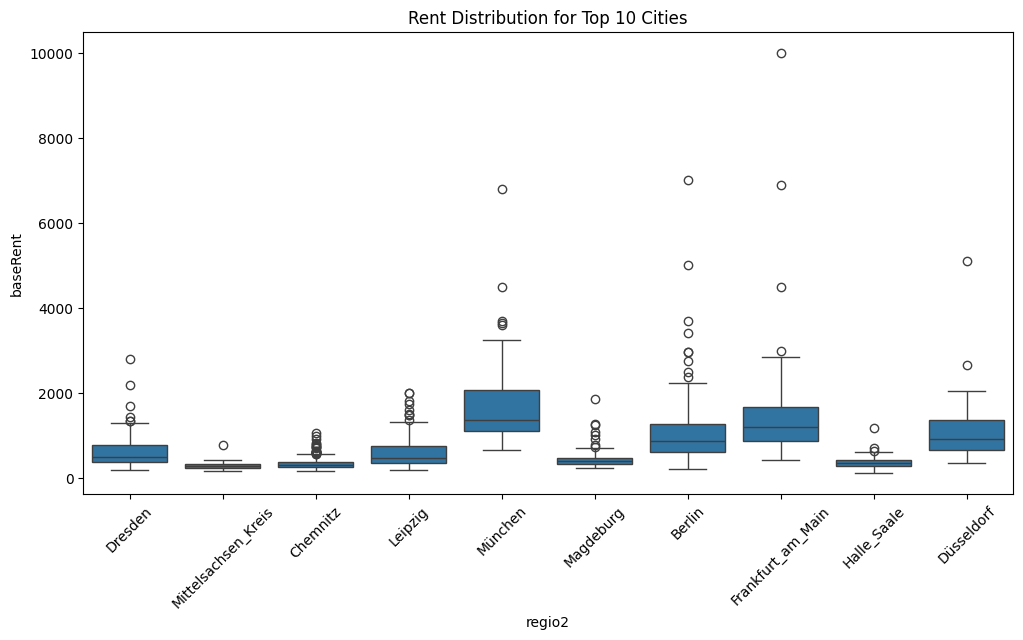

In [ ]:
plt.figure(figsize=(12,6))
top_cities = df_small["regio2"].value_counts().head(10).index
city_data = df_small[df_small["regio2"].isin(top_cities)]

sns.boxplot(data=city_data, x="regio2", y="baseRent")
plt.xticks(rotation=45)
plt.title("Rent Distribution for Top 10 Cities")
plt.show()


In [ ]:
df_encoded = pd.get_dummies(df_small, columns=["regio1", "regio2"], drop_first=True)
df_encoded.head()


,baseRent,livingSpace,noRooms,yearConstructed,regio1_Bayern,regio1_Berlin,regio1_Brandenburg,regio1_Bremen,regio1_Hamburg,regio1_Hessen,...,regio2_Wolfenbüttel_Kreis,regio2_Wolfsburg,regio2_Worms,regio2_Wunsiedel_im_Fichtelgebirge_Kreis,regio2_Wuppertal,regio2_Würzburg,regio2_Würzburg_Kreis,regio2_Zollernalbkreis,regio2_Zwickau,regio2_Zwickau_Kreis
0,595.0,86.00,4.0,1965.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,800.0,89.00,3.0,1871.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,965.0,83.80,3.0,2019.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,343.0,58.15,3.0,1964.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,765.0,84.97,3.0,1950.0,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X = df_encoded.drop("baseRent", axis=1)
y = df_encoded["baseRent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (3208, 391)
Test set: (802, 391)


In [ ]:
model = LinearRegression()

# Impute missing values in X_train and X_test
# Using the median strategy for numerical columns like 'yearConstructed'
imputer = SimpleImputer(strategy='median')

# Fit imputer on X_train and transform both X_train and X_test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame, retaining column names and index
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


MAE : 146.10
MSE : 65562.31
RMSE: 256.05
R²  : 0.705


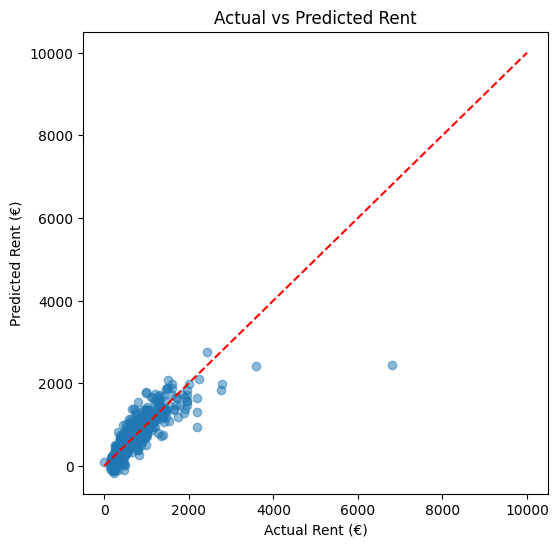

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

# Plot actual vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Rent (€)")
plt.ylabel("Predicted Rent (€)")
plt.title("Actual vs Predicted Rent")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.show()


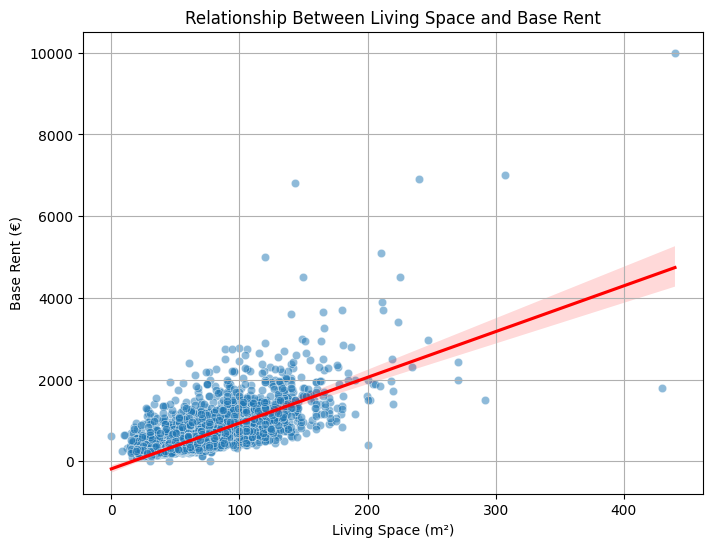

In [ ]:
# ============================================================
# 11. Rent vs Living Space (Scatter Plot with Trend)
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_small,
    x="livingSpace",
    y="baseRent",
    alpha=0.5
)

# Add a trend line
sns.regplot(
    data=df_small,
    x="livingSpace",
    y="baseRent",
    scatter=False,
    color="red"
)

plt.title("Relationship Between Living Space and Base Rent")
plt.xlabel("Living Space (m²)")
plt.ylabel("Base Rent (€)")
plt.grid(True)
plt.show()


In [ ]:
example_data = {
    "livingSpace": [40, 80, 120],
    "noRooms": [1, 3, 5],
    "yearConstructed": [1990, 2010, 1960],
    "regio1_Berlin": [1, 0, 0],
    "regio2_Berlin": [1, 0, 0]
}

# Create a DataFrame with all columns present in X, filling missing with 0
example = pd.DataFrame(example_data, index=["Small Berlin apt", "Medium apt", "Large apt"])
example = example.reindex(columns=X.columns, fill_value=0)

predicted = model.predict(example)
example["Predicted Rent (€)"] = predicted
example

,livingSpace,noRooms,yearConstructed,regio1_Bayern,regio1_Berlin,regio1_Brandenburg,regio1_Bremen,regio1_Hamburg,regio1_Hessen,regio1_Mecklenburg_Vorpommern,...,regio2_Wolfsburg,regio2_Worms,regio2_Wunsiedel_im_Fichtelgebirge_Kreis,regio2_Wuppertal,regio2_Würzburg,regio2_Würzburg_Kreis,regio2_Zollernalbkreis,regio2_Zwickau,regio2_Zwickau_Kreis,Predicted Rent (€)
Small Berlin apt,40,1,1990,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,793.200871
Medium apt,80,3,2010,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,797.452916
Large apt,120,5,1960,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1122.289127
